In [1]:
!pip install --upgrade google-cloud-storage tqdm opencv-python-headless pandas pillow scikit-learn


In [10]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.8/644.8 MB 53.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 125.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 145.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 127.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 116.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 128.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
!gcloud config set project ml-projects-460616 


Updated property [core/project].


In [1]:
import os
from google.cloud import storage
import zipfile

FILES={
    'train.zip': 'train.zip',
    'val.zip':'val.zip',
    'test.zip':'test.zip'
}

BUCKET_NAME ='yelp-dataset-photos'

DEST_DIR = "data"

os.makedirs(DEST_DIR, exist_ok=True)

client=storage.Client()
bucket=client.bucket(BUCKET_NAME)


def download_and_extract(zip_name):
    blob=bucket.blob(FILES[zip_name])
    local_path=os.path.join(DEST_DIR,zip_name)
    
    print(f"Downloading {zip_name}")
    
    blob.download_to_filename(local_path)
    
    print(f"Extracting {zip_name}")
    
    with zipfile.ZipFile(local_path, 'r') as zip_ref:
        zip_ref.extractall(os.path.join(DEST_DIR, zip_name.replace(".zip", "")))
    
    print(f"Done: {zip_name}\n")
        
for i in FILES:
    download_and_extract(i)
    
print("All files downloaded and extracted")



Extracting train.zip
Done: train.zip

Extracting val.zip
Done: val.zip

Extracting test.zip
Done: test.zip

All files downloaded and extracted


In [2]:
from google.cloud import storage
import os

bucket_name = "yelp-dataset-photos"
csv_files = {
    "train_augmented_metadata.csv": "train_augmented_metadata.csv",
    "val_metadata.csv": "val_metadata.csv",
    "test_metadata.csv": "test_metadata.csv"
}

local_dir = "./metadata"
os.makedirs(local_dir, exist_ok=True)

client = storage.Client()
bucket = client.bucket(bucket_name)

for remote_name, local_name in csv_files.items():
    blob = bucket.blob(remote_name)
    local_path = os.path.join(local_dir, local_name)
    blob.download_to_filename(local_path)
    print(f"Downloaded {remote_name} to {local_path}")


Downloaded train_augmented_metadata.csv to ./metadata/train_augmented_metadata.csv
Downloaded val_metadata.csv to ./metadata/val_metadata.csv
Downloaded test_metadata.csv to ./metadata/test_metadata.csv


In [3]:
# organizing labels

import os
import pandas as pd
from shutil import copy2

def organize_images(csv_path, image_dir, output_dir):
    df = pd.read_csv(csv_path)

    for _, row in df.iterrows():
        photo_id = str(row['photo_id'])
        label = row['label']

        src_path = os.path.join(image_dir, f"{photo_id}.jpg")
        dst_folder = os.path.join(output_dir, label)
        dst_path = os.path.join(dst_folder, f"{photo_id}.jpg")

        os.makedirs(dst_folder, exist_ok=True)

        if os.path.exists(src_path):
            copy2(src_path, dst_path)


image_root = "data"  
meta_paths = {
    'train': 'metadata/train_augmented_metadata.csv',
    'val': 'metadata/val_metadata.csv',
    'test': 'metadata/test_metadata.csv'
}
    
for split, csv_file in meta_paths.items():
    print(f"Processing {split} set")
    organize_images(
        csv_path=csv_file,
        image_dir=os.path.join(image_root, split, split),   
        output_dir=os.path.join("data_sorted", split)
    )    

Processing train set
Processing val set
Processing test set


In [4]:
for root, dirs, files in os.walk("data_sorted/train"):
    print(f"{root} - {len(files)} files")


data_sorted/train - 0 files
data_sorted/train/outside - 4001 files
data_sorted/train/drink - 3971 files
data_sorted/train/menu - 1191 files
data_sorted/train/inside - 4023 files
data_sorted/train/food - 4006 files


In [5]:
# import os
# import pandas as pd
# from shutil import copy2

# def organize_images(csv_path, image_dir, output_dir):
#     df = pd.read_csv(csv_path)

#     for _, row in df.iterrows():
#         photo_id = str(row['photo_id'])
#         label = row['label']

#         src_path = os.path.join(image_dir, f"{photo_id}.jpg")
#         dst_folder = os.path.join(output_dir, label)
#         dst_path = os.path.join(dst_folder, f"{photo_id}.jpg")

#         os.makedirs(dst_folder, exist_ok=True)

#         if os.path.exists(src_path):
#             copy2(src_path, dst_path)

# # Call the function
# organize_images(
#     csv_path="metadata/train_augmented_metadata.csv",
#     image_dir="data/train/train",                
# )


TypeError: organize_images() missing 1 required positional argument: 'output_dir'

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Normalizing
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)

# 2. Loading images
train_gen = train_datagen.flow_from_directory(
    "data_sorted/train",
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    "data_sorted/val",
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)


2025-05-28 00:56:22.522805: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-28 00:56:22.988792: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-28 00:56:23.406516: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748393783.731618    3747 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748393783.821612    3747 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748393784.602333    3747 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Found 17193 images belonging to 5 classes.
Found 2146 images belonging to 5 classes.


# CNN Model 1

In [5]:
# CNN Model 1

from tensorflow.keras import layers, models, Input

model = models.Sequential()


In [6]:
# First layer
model.add(Input(shape=(128, 128, 3)))  
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

2025-05-26 15:18:40.660618: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
# second layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

In [8]:
# Flatten the feature maps to 1D
model.add(layers.Flatten())

# Fully connected layer
model.add(layers.Dense(64, activation='relu'))

# Final output layer
model.add(layers.Dense(train_gen.num_classes, activation='softmax'))

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [10]:
CNN_history = model.fit(
    train_gen,                
    epochs=10,                
    validation_data=val_gen, 
    verbose=1                 

)


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 57s 104ms/step - accuracy: 0.4302 - loss: 1.4498 - val_accuracy: 0.5904 - val_loss: 1.0393
Epoch 2/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 54s 100ms/step - accuracy: 0.6348 - loss: 0.9452 - val_accuracy: 0.6016 - val_loss: 0.9947
Epoch 3/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 53s 99ms/step - accuracy: 0.7077 - loss: 0.7753 - val_accuracy: 0.6892 - val_loss: 0.8405
Epoch 4/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 53s 99ms/step - accuracy: 0.7808 - loss: 0.5835 - val_accuracy: 0.6901 - val_loss: 0.8816
Epoch 5/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 54s 99ms/step - accuracy: 0.8530 - loss: 0.4028 - val_accuracy: 0.7106 - val_loss: 0.9042
Epoch 6/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 52s 97ms/step - accuracy: 0.9120 - loss: 0.2518 - val_accuracy: 0.6715 - val_loss: 1.0841
Epoch 7/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 53s 98ms/step - accuracy: 0.9526 - loss: 0.1495 - val_accuracy: 0.6710 - val_loss: 1.4130
Epoch 8/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 53s 98ms/step - accuracy: 0.9721 - loss: 0.0889 

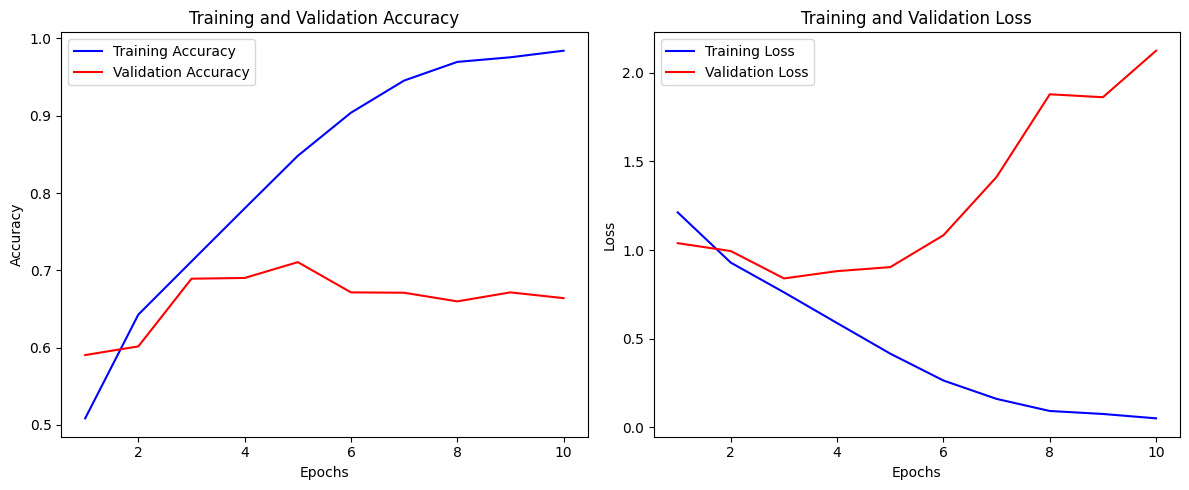

In [11]:
import matplotlib.pyplot as plt


acc     = CNN_history.history['accuracy']
val_acc = CNN_history.history['val_accuracy']
loss     = CNN_history.history['loss']
val_loss = CNN_history.history['val_loss']
epochs   = range(1, len(acc) + 1)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd


train_df = pd.read_csv("metadata/train_augmented_metadata.csv")
val_df = pd.read_csv("metadata/val_metadata.csv")
test_df = pd.read_csv("metadata/test_metadata.csv")


for df in [train_df, val_df, test_df]:
    df['photo_id'] = df['label'] + '/' + df['photo_id'].astype(str) + ".jpg"


eval_datagen = ImageDataGenerator(rescale=1./255)

# evaluation purpose genrators
train_eval_gen = eval_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory="data_sorted/train",
    x_col="photo_id",
    y_col="label",
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

val_eval_gen = eval_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory="data_sorted/val",
    x_col="photo_id",
    y_col="label",
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_generator = eval_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory="data_sorted/test",
    x_col="photo_id",
    y_col="label",
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)


Found 17192 validated image filenames belonging to 5 classes.
Found 2146 validated image filenames belonging to 5 classes.
Found 2149 validated image filenames belonging to 5 classes.


/opt/conda/lib/python3.10/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 4 invalid image filename(s) in x_col="photo_id". These filename(s) will be ignored.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="photo_id". These filename(s) will be ignored.
  warnings.warn(


In [16]:
# Evaluation Function

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import label_binarize

def evaluate_model(model, generator, title="Model Evaluation"):
    print(f"\n Evaluating on {title} set")

    # Prediction
    y_pred_proba = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = generator.classes
    class_labels = list(generator.class_indices.keys())

    # Accuracy
    _, acc = model.evaluate(generator, verbose=0)
    print(f"\n{title} Accuracy: {acc * 100:.2f}%")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_labels))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    # AUC Score (macro)
    try:
        y_true_bin = label_binarize(y_true, classes=np.arange(len(class_labels)))
        auc_macro = roc_auc_score(y_true_bin, y_pred_proba, average='macro', multi_class='ovr')
        aucs = roc_auc_score(y_true_bin, y_pred_proba, average=None, multi_class='ovr')
        print(f"\n AUC Score (macro average): {auc_macro:.4f}")
        for i, label in enumerate(class_labels):
            print(f"   • AUC for class '{label}': {aucs[i]:.4f}")
    except Exception as e:
        print(f"\n AUC calculation failed: {e}")

    # ROC Curve per class
    try:
        fpr = {}
        tpr = {}
        for i in range(len(class_labels)):
            fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])

        plt.figure(figsize=(10, 7))
        for i in range(len(class_labels)):
            roc_auc = auc(fpr[i], tpr[i])
            plt.plot(fpr[i], tpr[i], label=f"{class_labels[i]} (AUC = {roc_auc:.2f})")
        plt.plot([0, 1], [0, 1], 'k--', lw=1)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f"ROC Curves - {title}")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"\n ROC curve plotting failed: {e}")



 Evaluating on Train set
538/538 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step

Train Accuracy: 99.13%

Classification Report:
              precision    recall  f1-score   support

       drink       1.00      0.99      0.99      3971
        food       1.00      0.99      1.00      4006
      inside       0.99      0.98      0.99      4023
        menu       0.99      0.99      0.99      1191
     outside       0.98      1.00      0.99      4001

    accuracy                           0.99     17192
   macro avg       0.99      0.99      0.99     17192
weighted avg       0.99      0.99      0.99     17192



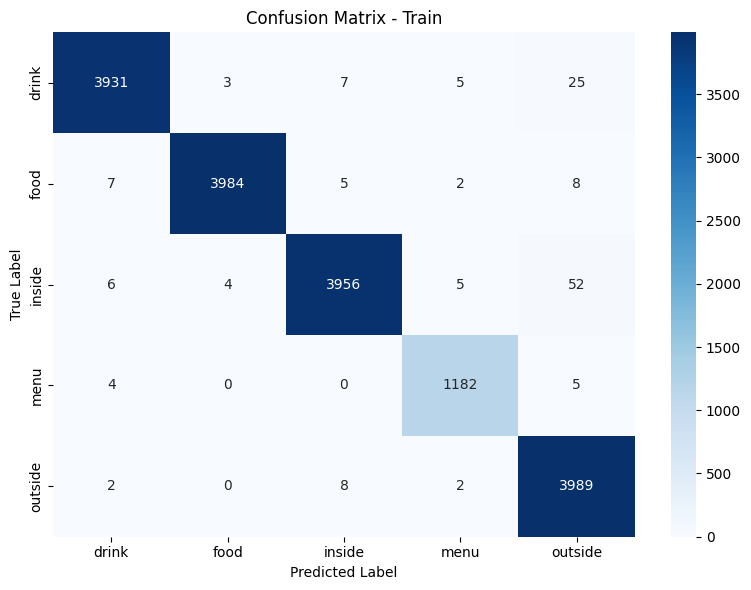


📈 AUC Score (macro average): 0.9999
   • AUC for class 'drink': 0.9999
   • AUC for class 'food': 1.0000
   • AUC for class 'inside': 0.9998
   • AUC for class 'menu': 0.9998
   • AUC for class 'outside': 0.9999


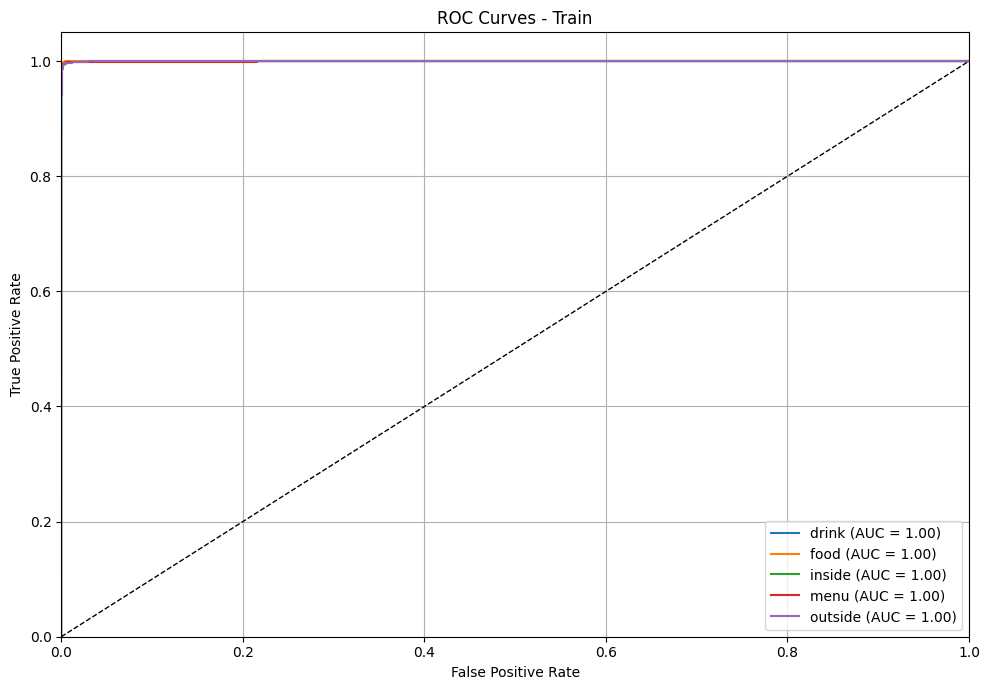

In [17]:
evaluate_model(model, train_eval_gen, "Train")




🔍 Evaluating on Validation set...
 3/68 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step

/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step

✅ Validation Accuracy: 66.40%

📄 Classification Report:
              precision    recall  f1-score   support

       drink       0.71      0.56      0.62       522
        food       0.79      0.76      0.78       486
      inside       0.61      0.60      0.61       481
        menu       0.54      0.63      0.58       157
     outside       0.61      0.76      0.68       500

    accuracy                           0.66      2146
   macro avg       0.65      0.66      0.65      2146
weighted avg       0.67      0.66      0.66      2146



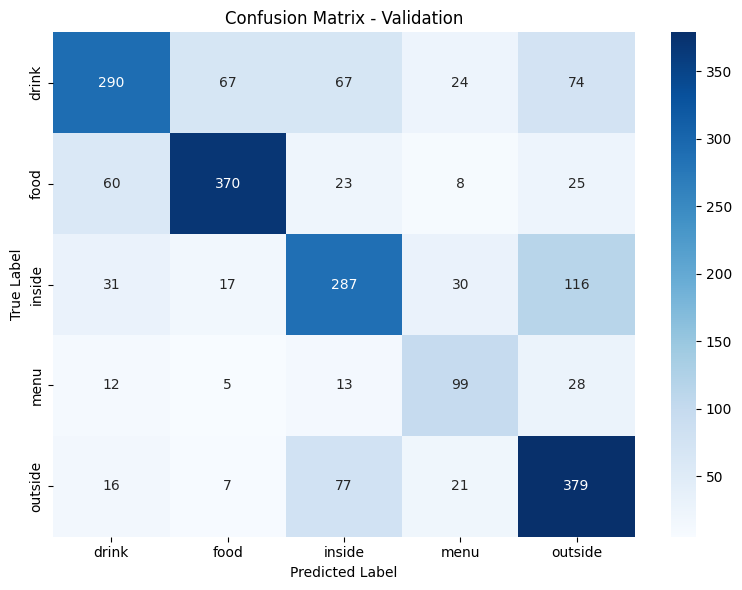


📈 AUC Score (macro average): 0.8949
   • AUC for class 'drink': 0.8746
   • AUC for class 'food': 0.9466
   • AUC for class 'inside': 0.8653
   • AUC for class 'menu': 0.8929
   • AUC for class 'outside': 0.8951


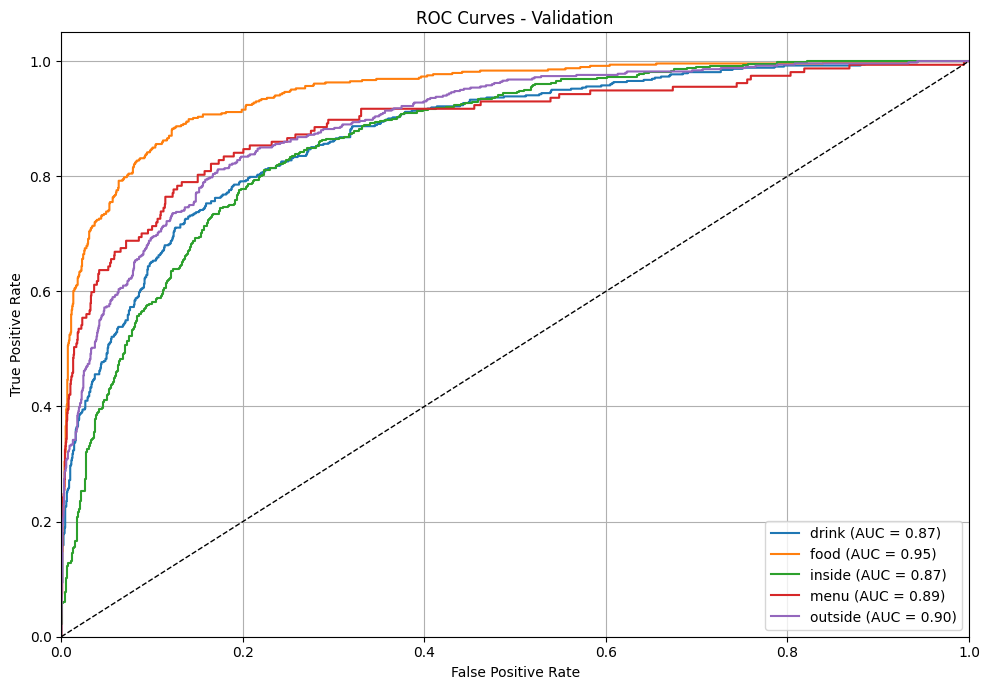

In [15]:
evaluate_model(model, val_eval_gen, "Validation")

Evaluation:

1. Training has 98% accuracy, but validation has only 65%. Model clearly overfits the data.
2. Model eventhough has less accuracy but is able to rank correct classes higher then wrong ones which is told by with macro AUC 89%

Next steps:

1. Add regularization
2. intriduce early stopping
3. Decrease filters

# CNN Model-2

In [30]:
from tensorflow.keras import models, layers, regularizers, callbacks, Input


model = models.Sequential()

# Input Layer
model.add(Input(shape=(128, 128, 3)))

# Convolutionallayer 1
model.add(layers.Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

# Convolutional layer 2
model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

#  L2 and Dropout
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu',
                       kernel_regularizer=regularizers.l2(0.001)))
model.add(layers.Dropout(0.5))

# Output Layer
model.add(layers.Dense(train_gen.num_classes, activation='softmax'))


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# EarlyStopping
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


In [31]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,  
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
538/538 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - accuracy: 0.4499 - loss: 1.4292 - val_accuracy: 0.5797 - val_loss: 1.1809
Epoch 2/20
538/538 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.5704 - loss: 1.2037 - val_accuracy: 0.6682 - val_loss: 1.0217
Epoch 3/20
538/538 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.6309 - loss: 1.1210 - val_accuracy: 0.6831 - val_loss: 1.0354
Epoch 4/20
538/538 ━━━━━━━━━━━━━━━━━━━━ 29s 54ms/step - accuracy: 0.6725 - loss: 1.0822 - val_accuracy: 0.7232 - val_loss: 0.9817
Epoch 5/20
538/538 ━━━━━━━━━━━━━━━━━━━━ 29s 54ms/step - accuracy: 0.7060 - loss: 1.0044 - val_accuracy: 0.6906 - val_loss: 1.0857
Epoch 6/20
538/538 ━━━━━━━━━━━━━━━━━━━━ 30s 55ms/step - accuracy: 0.7202 - loss: 1.0080 - val_accuracy: 0.7125 - val_loss: 1.0389
Epoch 7/20
538/538 ━━━━━━━━━━━━━━━━━━━━ 30s 55ms/step - accuracy: 0.7371 - loss: 0.9633 - val_accuracy: 0.6897 - val_loss: 1.1035



 Evaluating on Train set
538/538 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step

Train Accuracy: 78.19%

Classification Report:
              precision    recall  f1-score   support

       drink       0.74      0.77      0.75      3971
        food       0.85      0.89      0.87      4006
      inside       0.73      0.72      0.72      4023
        menu       0.93      0.60      0.73      1191
     outside       0.78      0.81      0.79      4001

    accuracy                           0.78     17192
   macro avg       0.81      0.76      0.77     17192
weighted avg       0.79      0.78      0.78     17192



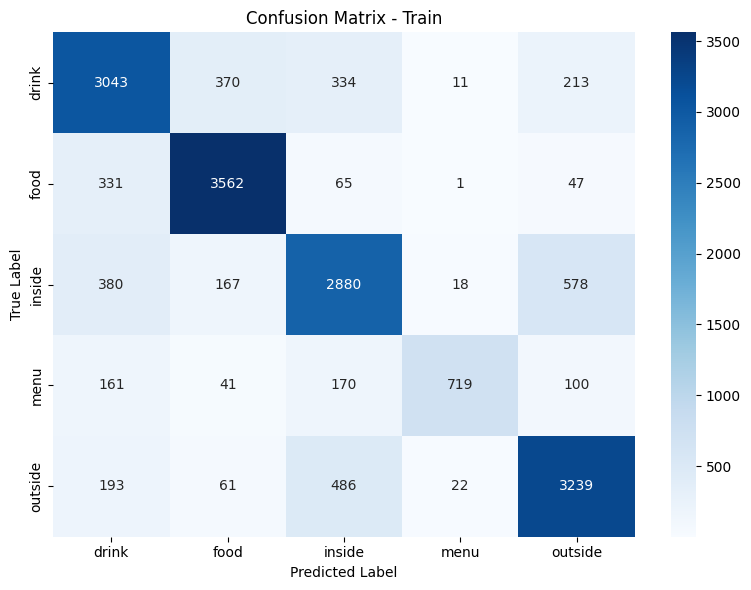


📈 AUC Score (macro average): 0.9510
   • AUC for class 'drink': 0.9321
   • AUC for class 'food': 0.9786
   • AUC for class 'inside': 0.9288
   • AUC for class 'menu': 0.9633
   • AUC for class 'outside': 0.9521


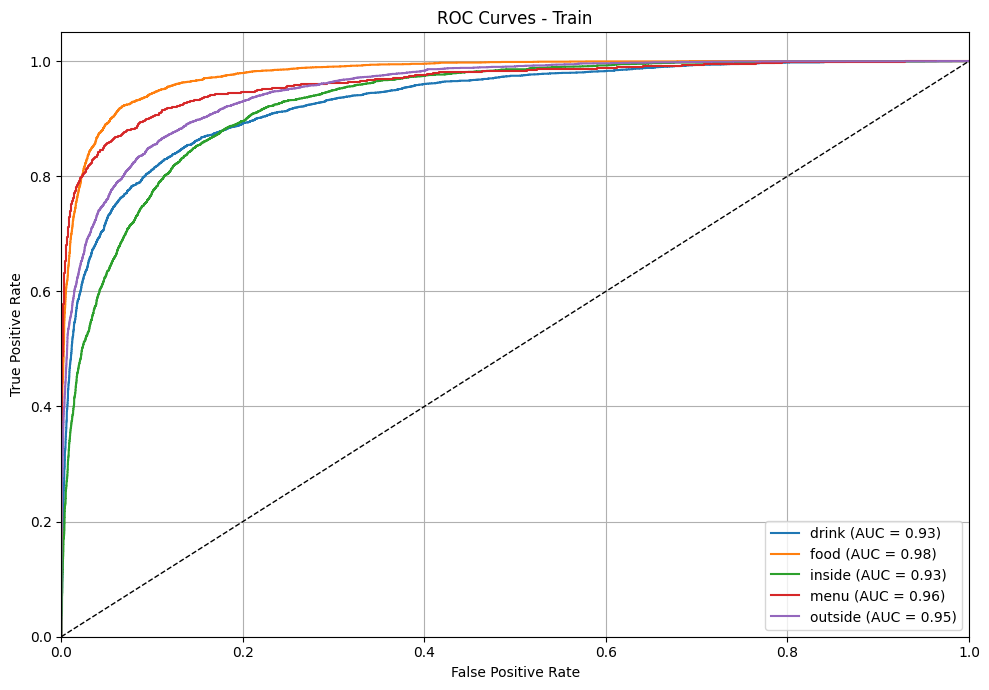

In [32]:
evaluate_model(model, train_eval_gen, "Train")


 Evaluating on val set
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

val Accuracy: 72.32%

Classification Report:
              precision    recall  f1-score   support

       drink       0.75      0.65      0.69       522
        food       0.81      0.84      0.82       486
      inside       0.66      0.72      0.69       481
        menu       0.74      0.55      0.63       157
     outside       0.69      0.75      0.72       500

    accuracy                           0.72      2146
   macro avg       0.73      0.70      0.71      2146
weighted avg       0.73      0.72      0.72      2146



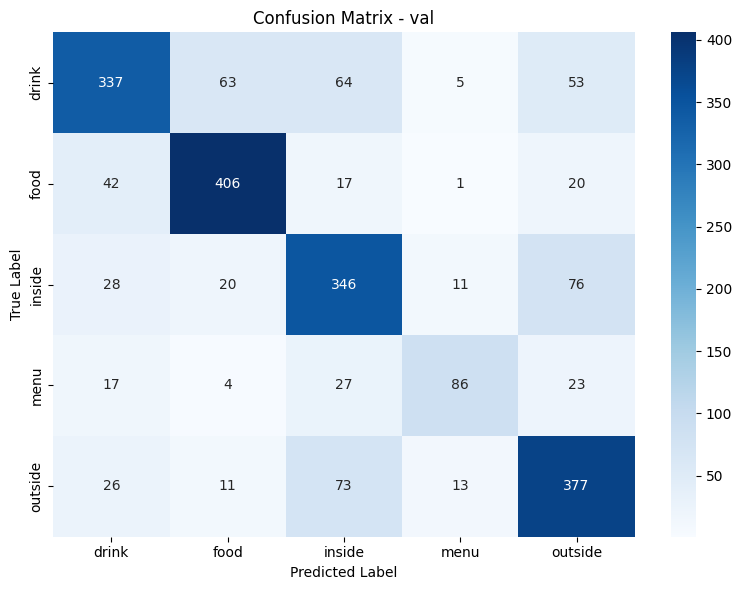


📈 AUC Score (macro average): 0.9213
   • AUC for class 'drink': 0.8880
   • AUC for class 'food': 0.9550
   • AUC for class 'inside': 0.9061
   • AUC for class 'menu': 0.9373
   • AUC for class 'outside': 0.9199


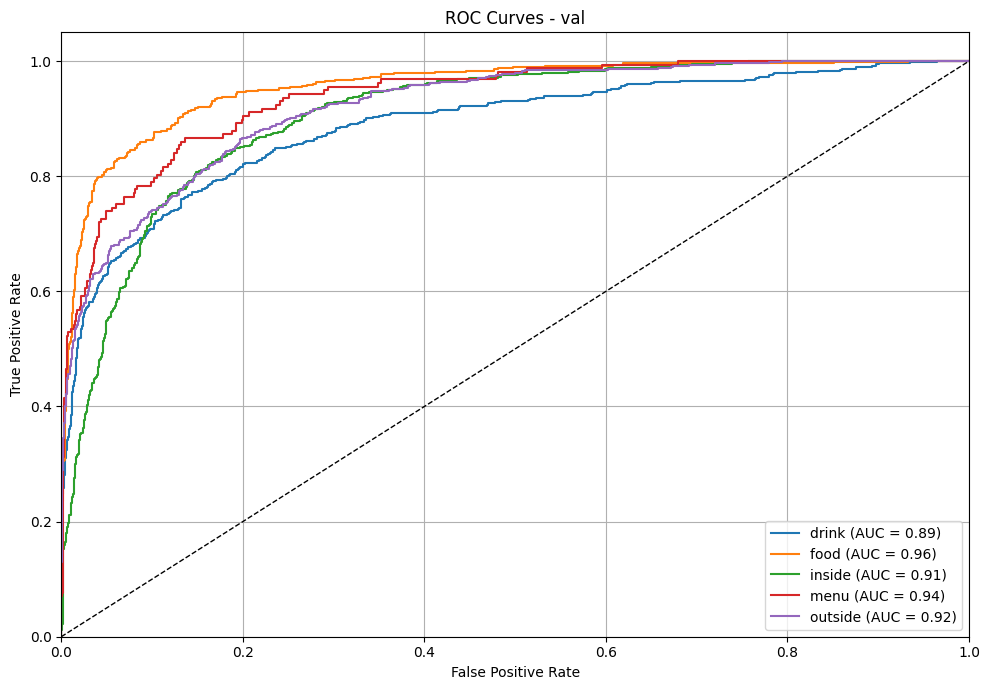

In [33]:
evaluate_model(model, val_eval_gen, "val")

In [10]:
# Tracking evalution Metrics 

def log_accuracy_auc(model_name, dataset_name, accuracy, auc_score, save_path=None):
    
    entry = {
    
        "model_name": model_name,
        "dataset": dataset_name,
        "accuracy": round(accuracy * 100, 2),
        "auc": round(auc_score, 4)
    }

    df = pd.DataFrame([entry])

    if save_path:
        try:
            
            existing_df = pd.read_csv(save_path)
            df = pd.concat([existing_df, df], ignore_index=True)
        except FileNotFoundError:
            pass 

        df.to_csv(save_path, index=False)
        print(f" Log saved to: {save_path}")

    return df



 Evaluating on val set
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

val Accuracy: 71.48%

Classification Report:
              precision    recall  f1-score   support

       drink       0.73      0.60      0.66       507
        food       0.81      0.85      0.83       495
      inside       0.62      0.66      0.64       496
        menu       0.72      0.55      0.62       152
     outside       0.70      0.80      0.74       499

    accuracy                           0.71      2149
   macro avg       0.72      0.69      0.70      2149
weighted avg       0.72      0.71      0.71      2149



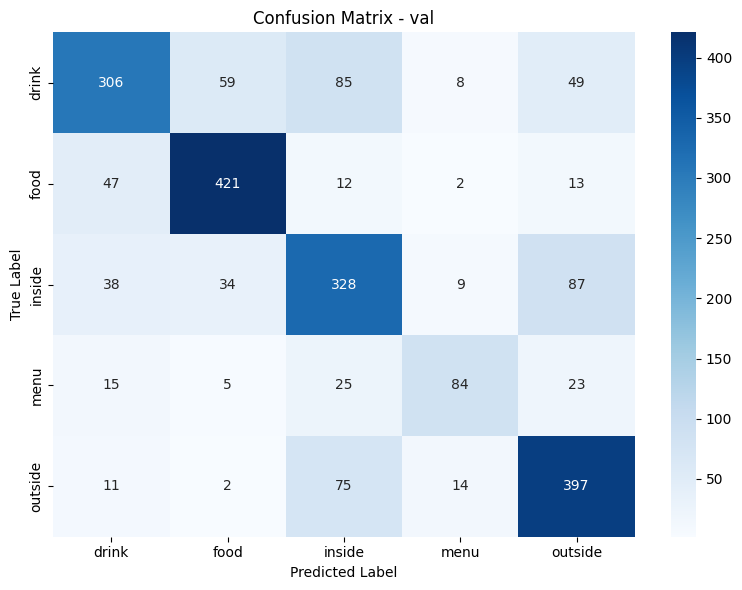


📈 AUC Score (macro average): 0.9229
   • AUC for class 'drink': 0.8903
   • AUC for class 'food': 0.9696
   • AUC for class 'inside': 0.8842
   • AUC for class 'menu': 0.9365
   • AUC for class 'outside': 0.9341


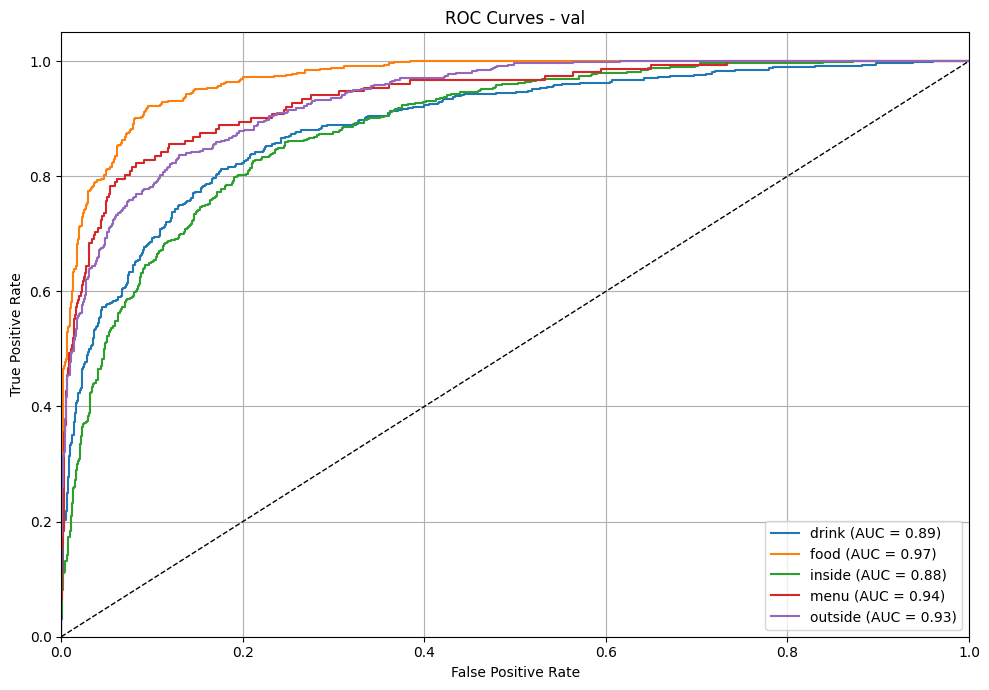

In [34]:
evaluate_model(model, test_generator, "val")

In [12]:
# log_accuracy_auc(
#     model_name="CNN_model1",
#     dataset_name="test",
#     accuracy=0.72,             
#     auc_score=0.92,             
#     save_path="evaluation_summary.csv"
# )


 Log saved to: evaluation_summary.csv


,model_name,dataset,accuracy,auc
0,CNN_model1,train,78.0,0.95
1,CNN_model1,test,72.0,0.92


Evaluation summary:

1. Train accuracy is 78% and AUC is 95%.
2. Test accuracy is 71.5% and AUC is 92%.
3. Model is confusing between Inside image and Outside image and Menu being confused with both Inside and Outside.
4. 85% of food images are being identified correctly.

Overall, CNN model 2 is able to identify almost 72% of images correctly with 92% confidence in ranking correct image apart from other images. CNN model is achieving good seperability of classes or images with decent accuracy.


Next Steps:
1. Further model tuning
2. Modifying architecture.
3. Filters and nodes.
4. Hyperparameter training.
5. Training on more images

In [36]:
#model.save("cnn_yelp_model1.keras")


In [9]:
# from tensorflow.keras.models import load_model
# model = load_model("cnn_yelp_model1.keras")


2025-05-28 01:15:41.865786: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/opt/conda/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
